# Phase 2A: relational representation requirements

## Scope

This is a **representation-design diagnostic**, not a modeling phase. It reuses Metrica Sample Game 1 and fixed Phase 1 cases to ask what information a defensive-organization representation must preserve when centroid-relative or single-reference views fail.

The primary anchor is the Phase 1F reception-anchored case at **1230.12 s**, where local defensive relations reorganize while whole-team centroid movement remains small. Controls and counterexamples are inherited from Phases 1A, 1C, 1E, and 1F; no new window search is performed.

Candidate views remain separate: centroid-relative coordinates, defender–defender geometry, defender–opponent geometry, directly interpretable depth differences, ball-relative position, and a descriptive local neighborhood. None is treated as an assignment, tactical state, score, or final representation. Distances do not establish responsibility, openness, defensive quality, or causality.

In [1]:
from pathlib import Path
import hashlib
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'metrica_sample_game_1'
HOME_PATH = DATA / 'Sample_Game_1_RawTrackingData_Home_Team.csv'
AWAY_PATH = DATA / 'Sample_Game_1_RawTrackingData_Away_Team.csv'
EVENT_PATH = DATA / 'Sample_Game_1_RawEventsData.csv'
LENGTH, WIDTH = 105.0, 68.0

def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

display(pd.DataFrame({
    'file': [p.name for p in (HOME_PATH, AWAY_PATH, EVENT_PATH)],
    'sha256': [sha256(p) for p in (HOME_PATH, AWAY_PATH, EVENT_PATH)],
}))

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...
2,Sample_Game_1_RawEventsData.csv,097dda6345e17390dca095331458fd00e47960c480c76f...


In [2]:
def load_tracking(path, team):
    header = pd.read_csv(path, header=None, nrows=3)
    ids = [str(int(float(v))) for v in header.iloc[1, 3:-2:2] if pd.notna(v)]
    cols = ['Period', 'Frame', 'Time [s]']
    for pid in ids:
        cols += [f'{team}_{pid}_x', f'{team}_{pid}_y']
    cols += [f'{team}_ball_x', f'{team}_ball_y']
    return pd.read_csv(path, skiprows=3, names=cols), ids

home, home_players = load_tracking(HOME_PATH, 'Home')
away, away_players = load_tracking(AWAY_PATH, 'Away')
events = pd.read_csv(EVENT_PATH)
tracking = {'Home': home, 'Away': away}
players = {'Home': home_players, 'Away': away_players}
goalkeeper = {'Home': '11', 'Away': '25'}
print({'Home': home.shape, 'Away': away.shape, 'events': events.shape})

{'Home': (145006, 33), 'Away': (145006, 33), 'events': (1745, 14)}


## Fixed cases

The cases below are inherited without searching for numerically favorable behavior. “Selected defenders” are only players already used in the relevant Phase 1 diagnostic. Where an earlier case had no fixed defender subset, the focal defender plus the two nearest defending outfield teammates at the first frame are displayed as a **descriptive local neighborhood**, not a unit or inferred responsibility set.

In [3]:
CASES = [
    {'name':'coordinated collective movement', 'source':'Phase 1A', 'period':1, 'start':1888.0, 'end':1896.0,
     'def_team':'Home', 'focal':'2', 'opp_team':'Away', 'opponent':None, 'selected_defs':None, 'secondary_opponents':[]},
    {'name':'apparent individual excursion', 'source':'Phase 1A/1D', 'period':1, 'start':590.0, 'end':598.0,
     'def_team':'Home', 'focal':'2', 'opp_team':'Away', 'opponent':'23', 'selected_defs':None, 'secondary_opponents':[]},
    {'name':'tackle / engagement', 'source':'Phase 1C/1E', 'period':1, 'start':550.76, 'end':555.76,
     'def_team':'Away', 'focal':'16', 'opp_team':'Home', 'opponent':'9', 'selected_defs':None, 'secondary_opponents':[]},
    {'name':'primary interior-threat anchor', 'source':'Phase 1F', 'period':1, 'start':1228.12, 'end':1232.12,
     'def_team':'Away', 'focal':'19', 'opp_team':'Home', 'opponent':'10', 'selected_defs':['19','20','21'], 'secondary_opponents':['6','7','5'], 'anchor':1230.12},
    {'name':'collective accommodation / engagement', 'source':'Phase 1E', 'period':1, 'start':1229.28, 'end':1234.28,
     'def_team':'Away', 'focal':'19', 'opp_team':'Home', 'opponent':'10', 'selected_defs':['19','20','21'], 'secondary_opponents':['6','7','5'], 'anchor':1232.28},
    {'name':'collective-translation contrast', 'source':'Phase 1E', 'period':2, 'start':3679.88, 'end':3684.88,
     'def_team':'Home', 'focal':'8', 'opp_team':'Away', 'opponent':'15', 'selected_defs':None, 'secondary_opponents':[],'anchor':3682.88},
    {'name':'negative interior-threat case', 'source':'Phase 1F', 'period':2, 'start':4195.04, 'end':4199.04,
     'def_team':'Away', 'focal':'16', 'opp_team':'Home', 'opponent':'10', 'selected_defs':['16','18','21'], 'secondary_opponents':['12','6','3'], 'anchor':4197.04},
]
display(pd.DataFrame(CASES)[['name','source','period','start','end','def_team','focal','opp_team','opponent']])

,name,source,period,start,end,def_team,focal,opp_team,opponent
0,coordinated collective movement,Phase 1A,1,1888.00,1896.00,Home,2,Away,None
1,apparent individual excursion,Phase 1A/1D,1,590.00,598.00,Home,2,Away,23
2,tackle / engagement,Phase 1C/1E,1,550.76,555.76,Away,16,Home,9
3,primary interior-threat anchor,Phase 1F,1,1228.12,1232.12,Away,19,Home,10
4,collective accommodation / engagement,Phase 1E,1,1229.28,1234.28,Away,19,Home,10
5,collective-translation contrast,Phase 1E,2,3679.88,3684.88,Home,8,Away,15
6,negative interior-threat case,Phase 1F,2,4195.04,4199.04,Away,16,Home,10


In [4]:
def case_window(case):
    d = tracking[case['def_team']]
    o = tracking[case['opp_team']]
    w = d[(d['Period'] == case['period']) & d['Time [s]'].between(case['start'], case['end'])].copy()
    opponent_cols = ['Frame'] + [f"{case['opp_team']}_{p}_{axis}" for p in players[case['opp_team']] for axis in ('x','y')]
    return w.merge(o[opponent_cols], on='Frame', validate='one_to_one')

def outfield(case):
    return [p for p in players[case['def_team']] if p != goalkeeper[case['def_team']]]

def metric_xy(row, team, pid):
    return np.array([row[f'{team}_{pid}_x'] * LENGTH, row[f'{team}_{pid}_y'] * WIDTH], dtype=float)

def nearest_local_ids(case, w, count=3):
    if case.get('selected_defs'):
        return case['selected_defs']
    first = w.iloc[0]
    focal_xy = metric_xy(first, case['def_team'], case['focal'])
    candidates = []
    for p in outfield(case):
        if p == case['focal']:
            continue
        xy = metric_xy(first, case['def_team'], p)
        if np.isfinite(xy).all():
            candidates.append((np.linalg.norm(xy-focal_xy), p))
    return [case['focal']] + [p for _,p in sorted(candidates)[:count-1]]

def add_geometry(case):
    w = case_window(case)
    team = case['def_team']
    ids = outfield(case)
    w['centroid_x_m'] = w[[f'{team}_{p}_x' for p in ids]].mean(axis=1) * LENGTH
    w['centroid_y_m'] = w[[f'{team}_{p}_y' for p in ids]].mean(axis=1) * WIDTH
    refs = [p for p in ids if p != case['focal']]
    w['loo_x_m'] = w[[f'{team}_{p}_x' for p in refs]].mean(axis=1) * LENGTH
    w['loo_y_m'] = w[[f'{team}_{p}_y' for p in refs]].mean(axis=1) * WIDTH
    w['focal_centroid_rel_x_m'] = w[f"{team}_{case['focal']}_x"] * LENGTH - w['loo_x_m']
    w['focal_centroid_rel_y_m'] = w[f"{team}_{case['focal']}_y"] * WIDTH - w['loo_y_m']
    w['t_rel_s'] = w['Time [s]'] - (case.get('anchor') or case['start'])
    return w

for case in CASES:
    w = add_geometry(case)
    case['display_defs'] = nearest_local_ids(case, w)
    print(case['name'], {'frames':len(w), 'display_defenders':case['display_defs'], 'missing_ball_frames':int(w[f"{case['def_team']}_ball_x"].isna().sum())})

coordinated collective movement {'frames': 201, 'display_defenders': ['2', '3', '7'], 'missing_ball_frames': 0}
apparent individual excursion {'frames': 201, 'display_defenders': ['2', '3', '1'], 'missing_ball_frames': 0}
tackle / engagement {'frames': 126, 'display_defenders': ['16', '17', '15'], 'missing_ball_frames': 0}
primary interior-threat anchor {'frames': 101, 'display_defenders': ['19', '20', '21'], 'missing_ball_frames': 0}
collective accommodation / engagement {'frames': 126, 'display_defenders': ['19', '20', '21'], 'missing_ball_frames': 0}
collective-translation contrast {'frames': 126, 'display_defenders': ['8', '10', '5'], 'missing_ball_frames': 0}
negative interior-threat case {'frames': 101, 'display_defenders': ['16', '18', '21'], 'missing_ball_frames': 0}


## Soccer-first overview of every fixed sequence

These trajectory panels establish the visible soccer behavior before the relational views are compared. Start positions are circles and end positions are crosses. The local subset is emphasized only to make later pairwise plots legible.

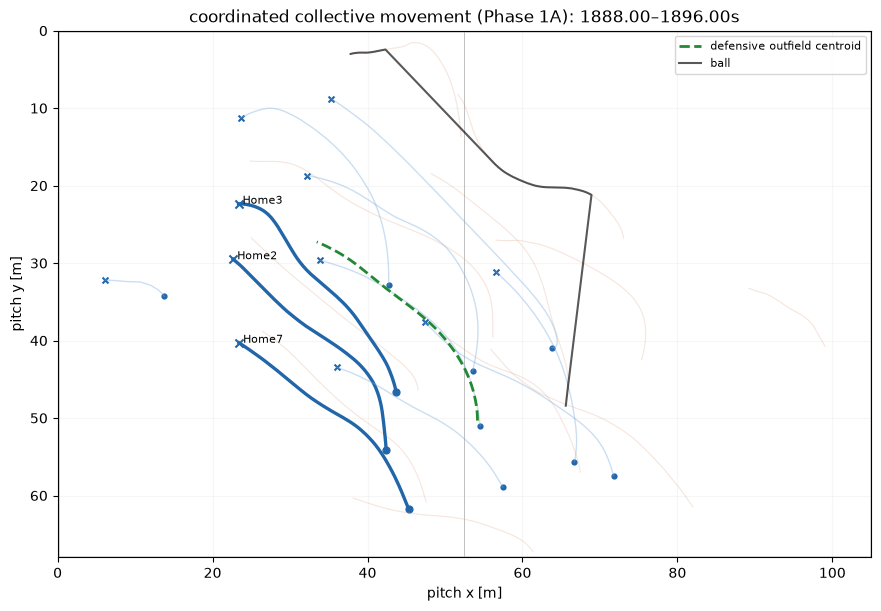

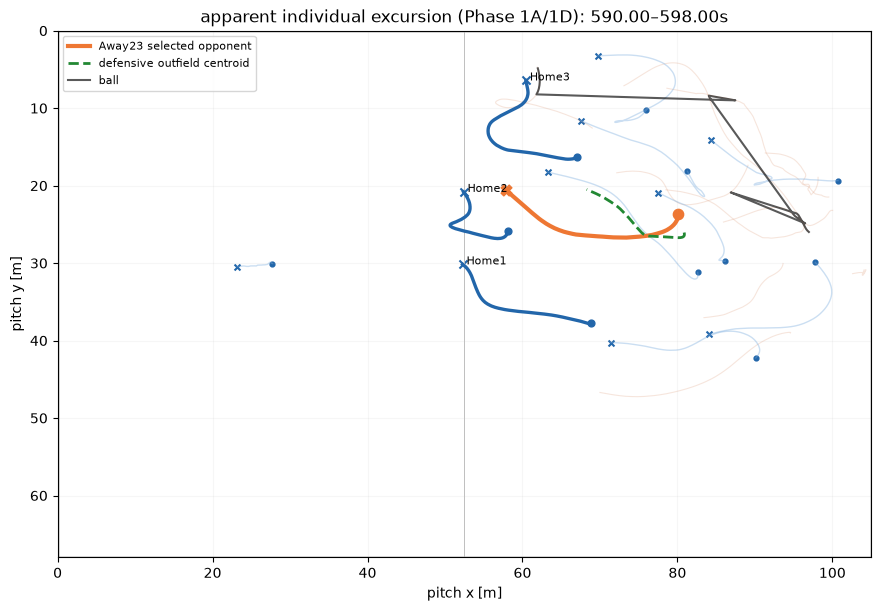

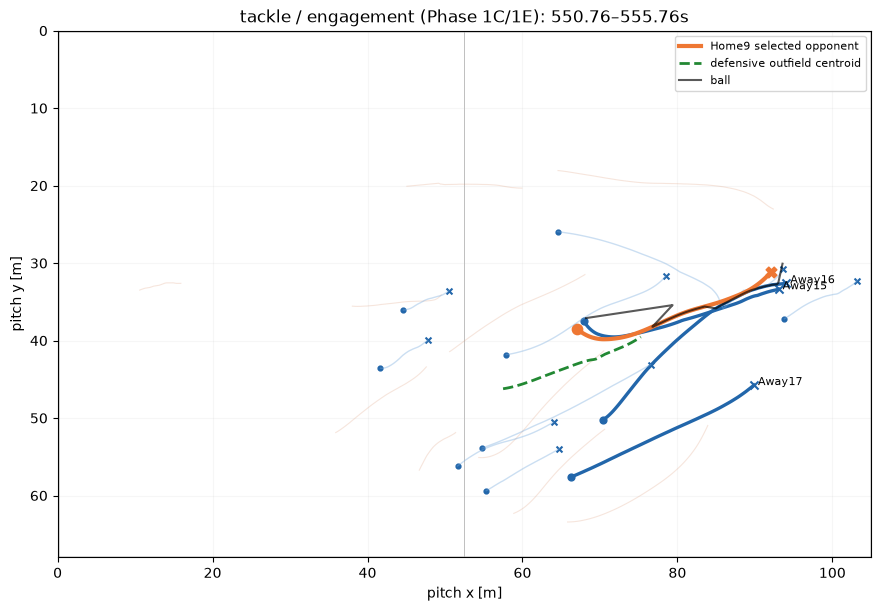

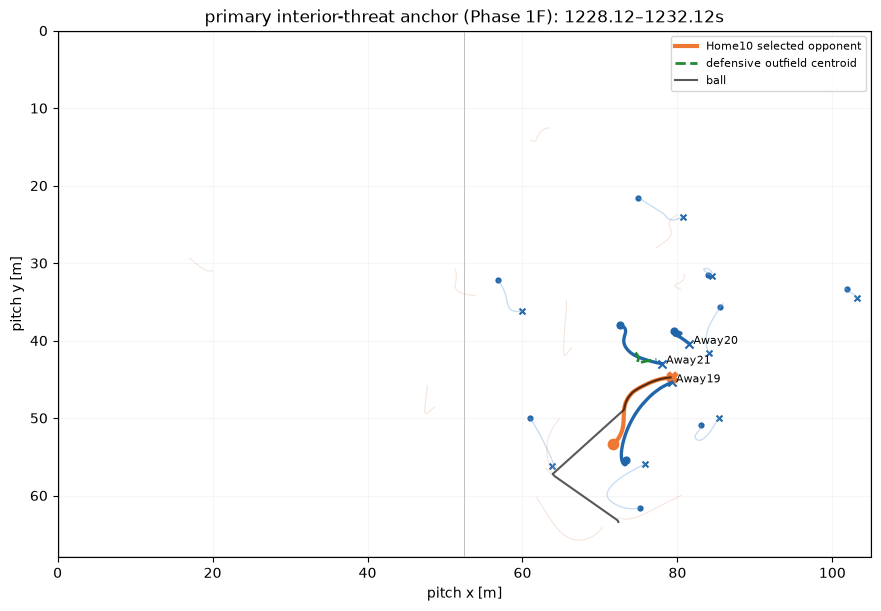

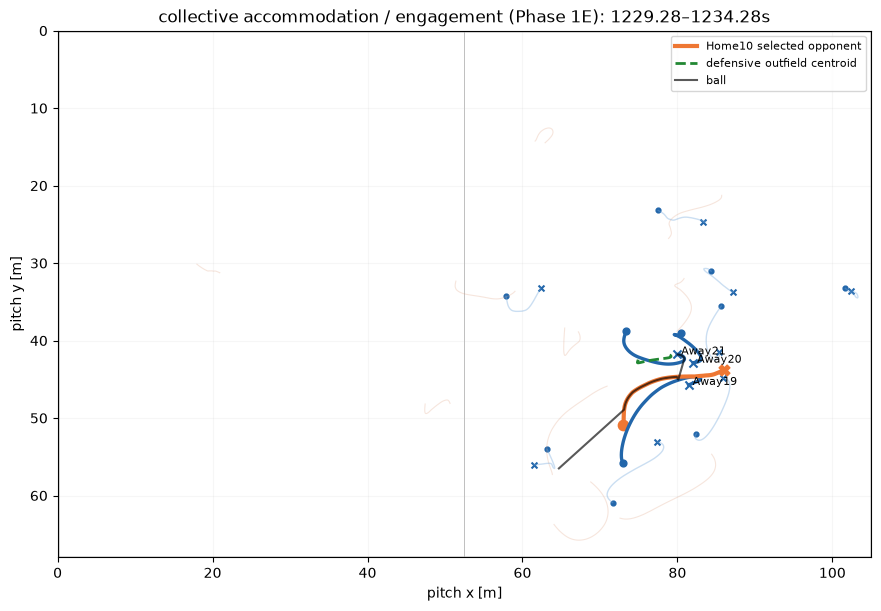

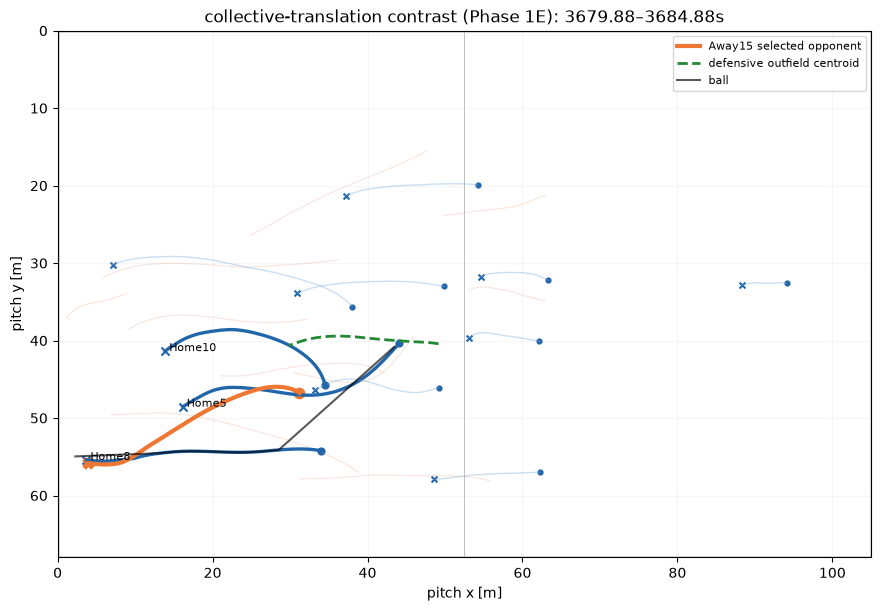

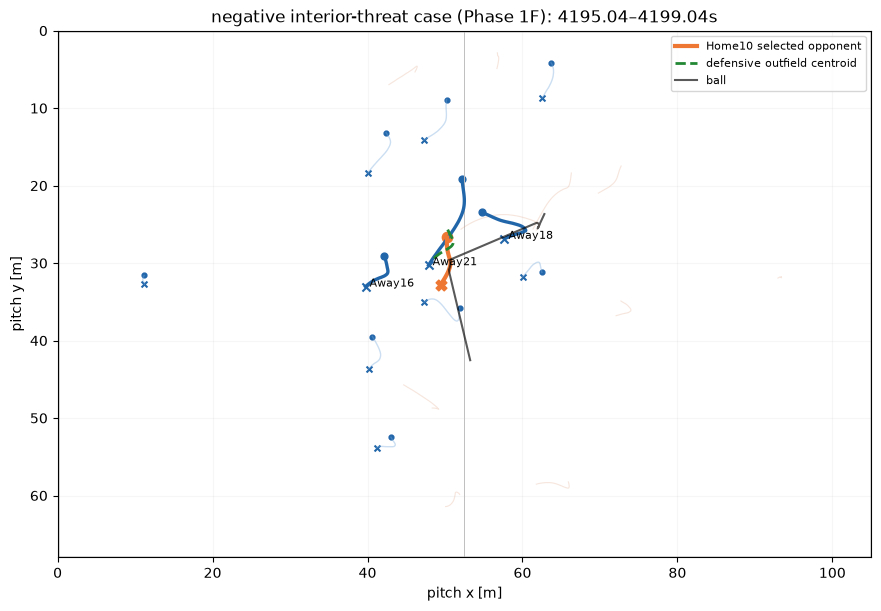

In [5]:
def pitch(ax):
    ax.plot([0,LENGTH,LENGTH,0,0],[0,0,WIDTH,WIDTH,0],color='0.35',lw=1)
    ax.axvline(LENGTH/2,color='0.75',lw=.7)
    ax.set(xlim=(0,LENGTH), ylim=(WIDTH,0), aspect='equal', xlabel='pitch x [m]', ylabel='pitch y [m]')
    ax.grid(alpha=.10)

def trajectory_overview(case):
    w = add_geometry(case); dt, ot = case['def_team'], case['opp_team']
    fig, ax = plt.subplots(figsize=(11,6), constrained_layout=True)
    pitch(ax)
    for p in players[ot]:
        x,y=w[f'{ot}_{p}_x']*LENGTH,w[f'{ot}_{p}_y']*WIDTH
        ax.plot(x,y,color='#dd9977',alpha=.25,lw=.8)
    for p in players[dt]:
        x,y=w[f'{dt}_{p}_x']*LENGTH,w[f'{dt}_{p}_y']*WIDTH
        emph=p in case['display_defs']
        ax.plot(x,y,color='#2266aa' if emph else '#77aadd',alpha=1 if emph else .38,lw=2.4 if emph else 1)
        if np.isfinite(x.iloc[0]): ax.scatter(x.iloc[0],y.iloc[0],color='#2266aa',s=24 if emph else 12)
        if np.isfinite(x.iloc[-1]): ax.scatter(x.iloc[-1],y.iloc[-1],color='#2266aa',marker='x',s=34 if emph else 18)
        if emph: ax.text(x.iloc[-1],y.iloc[-1],f' {dt}{p}',fontsize=8)
    if case['opponent']:
        x,y=w[f"{ot}_{case['opponent']}_x"]*LENGTH,w[f"{ot}_{case['opponent']}_y"]*WIDTH
        ax.plot(x,y,color='#ee7733',lw=3,label=f"{ot}{case['opponent']} selected opponent")
        ax.scatter(x.iloc[0],y.iloc[0],color='#ee7733',s=55); ax.scatter(x.iloc[-1],y.iloc[-1],color='#ee7733',marker='X',s=60)
    ax.plot(w['centroid_x_m'],w['centroid_y_m'],color='#228833',ls='--',lw=2,label='defensive outfield centroid')
    bx=w[f'{dt}_ball_x']*LENGTH; by=w[f'{dt}_ball_y']*WIDTH
    ax.plot(bx,by,color='black',lw=1.5,alpha=.65,label='ball')
    ax.set_title(f"{case['name']} ({case['source']}): {case['start']:.2f}–{case['end']:.2f}s")
    ax.legend(fontsize=8,loc='best')
    plt.show()

for case in CASES:
    trajectory_overview(case)

## Primary anchor: before / during / after

The three snapshots below show all players and the ball. Lines connect the three previously selected converging defenders to the focal interior attacker; defender–defender links show their local geometry; faint dotted links expose selected relationships to other attackers. They are descriptive pairwise relationships, not marking assignments.

The figure is intended to show the logical failure directly: a small movement of the green centroid can coexist with large, partially cancelling movements and changed local/opponent-relative geometry.

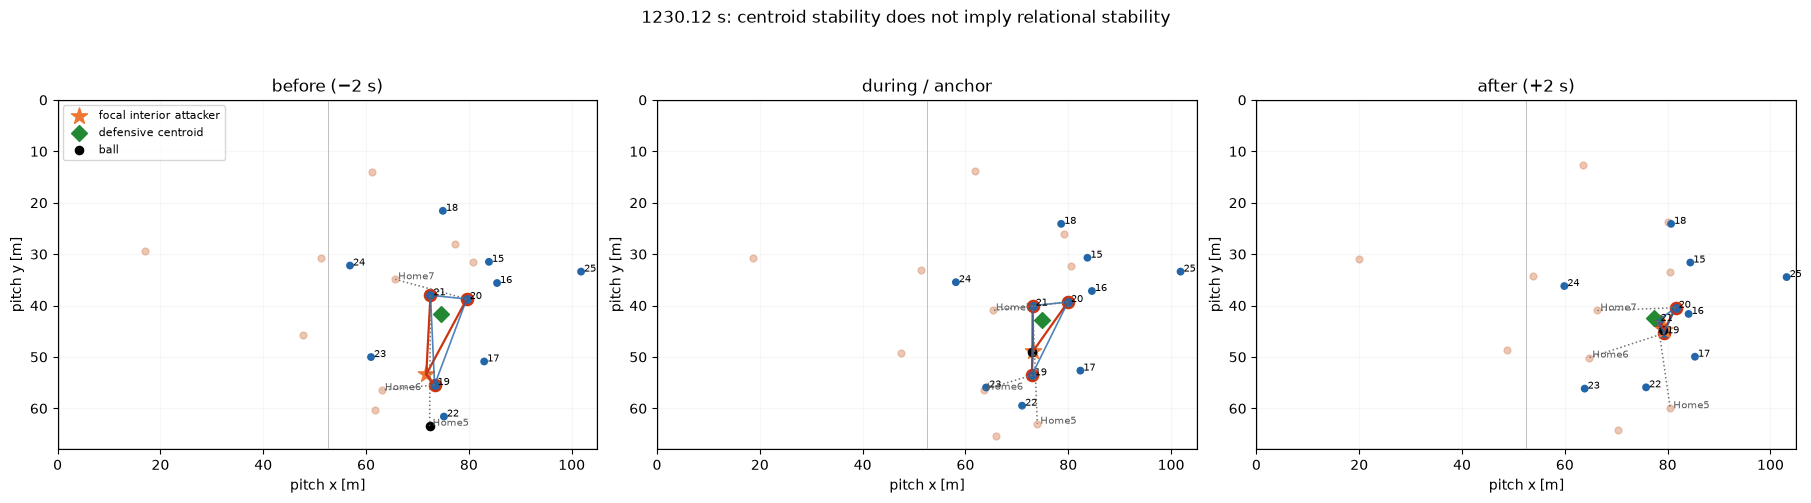

In [6]:
ANCHOR = next(c for c in CASES if c['name'] == 'primary interior-threat anchor')

def nearest_time_row(w, target):
    return w.loc[(w['Time [s]']-target).abs().idxmin()]

def anchor_snapshots(case):
    w=add_geometry(case); dt,ot=case['def_team'],case['opp_team']; offsets=[-2,0,2]
    fig,axes=plt.subplots(1,3,figsize=(18,5),constrained_layout=True)
    for ax,off in zip(axes,offsets):
        r=nearest_time_row(w,case['anchor']+off); pitch(ax)
        for p in players[ot]:
            xy=metric_xy(r,ot,p)
            ax.scatter(*xy,c='#dd9977',s=24,alpha=.55)
        for p in players[dt]:
            xy=metric_xy(r,dt,p); emph=p in case['selected_defs']
            ax.scatter(*xy,c='#2266aa',s=65 if emph else 32,edgecolor='#cc3311' if emph else 'none',linewidth=1.7)
            ax.text(*xy,f' {p}',fontsize=7)
        threat=metric_xy(r,ot,case['opponent'])
        ax.scatter(*threat,c='#ee7733',marker='*',s=150,label='focal interior attacker')
        for p in case['selected_defs']:
            dxy=metric_xy(r,dt,p); ax.plot([dxy[0],threat[0]],[dxy[1],threat[1]],c='#cc3311',lw=1.6)
        for p,q in itertools.combinations(case['selected_defs'],2):
            a,b=metric_xy(r,dt,p),metric_xy(r,dt,q); ax.plot([a[0],b[0]],[a[1],b[1]],c='#2266aa',lw=1.2,alpha=.8)
        for p,a in zip(case['selected_defs'],case['secondary_opponents']):
            dxy,axy=metric_xy(r,dt,p),metric_xy(r,ot,a); ax.plot([dxy[0],axy[0]],[dxy[1],axy[1]],c='0.45',ls=':',lw=1.1)
            ax.text(*axy,f' {ot}{a}',fontsize=7,color='0.35')
        ax.scatter(r['centroid_x_m'],r['centroid_y_m'],c='#228833',marker='D',s=65,label='defensive centroid')
        ax.scatter(r[f'{dt}_ball_x']*LENGTH,r[f'{dt}_ball_y']*WIDTH,c='black',s=35,label='ball')
        ax.set_title({-2:'before (−2 s)',0:'during / anchor',2:'after (+2 s)'}[off])
    axes[0].legend(fontsize=8,loc='upper left')
    fig.suptitle('1230.12 s: centroid stability does not imply relational stability',y=1.03)
    plt.show()

anchor_snapshots(ANCHOR)

In [7]:
def anchor_relationship_table(case):
    w=add_geometry(case); dt,ot=case['def_team'],case['opp_team']; rows=[]
    for label,off in [('before',-2),('during',0),('after',2)]:
        r=nearest_time_row(w,case['anchor']+off)
        row={'moment':label,'time_s':r['Time [s]'],'centroid_x_m':r['centroid_x_m'],'centroid_y_m':r['centroid_y_m']}
        threat=metric_xy(r,ot,case['opponent'])
        for p in case['selected_defs']:
            row[f'{dt}{p}_to_threat_m']=np.linalg.norm(metric_xy(r,dt,p)-threat)
        for p,q in itertools.combinations(case['selected_defs'],2):
            row[f'{dt}{p}_{dt}{q}_m']=np.linalg.norm(metric_xy(r,dt,p)-metric_xy(r,dt,q))
        for p,a in zip(case['selected_defs'],case['secondary_opponents']):
            rel=metric_xy(r,dt,p)-metric_xy(r,ot,a)
            row[f'{dt}{p}_minus_{ot}{a}_x_m']=rel[0]
            row[f'{dt}{p}_minus_{ot}{a}_y_m']=rel[1]
        rows.append(row)
    out=pd.DataFrame(rows)
    out['centroid_dx_from_before_m']=out['centroid_x_m']-out['centroid_x_m'].iloc[0]
    out['centroid_dy_from_before_m']=out['centroid_y_m']-out['centroid_y_m'].iloc[0]
    return out

anchor_table=anchor_relationship_table(ANCHOR)
display(anchor_table.round(3).T)

,0,1,2
moment,before,during,after
time_s,1228.12,1230.12,1232.12
centroid_x_m,74.574,74.84,77.291
centroid_y_m,41.556,42.842,42.439
Away19_to_threat_m,2.627,4.668,0.663
Away20_to_threat_m,16.638,11.774,4.845
Away21_to_threat_m,15.399,8.886,2.177
Away19_Away20_m,17.852,15.906,5.449
Away19_Away21_m,17.462,13.55,2.731
Away20_Away21_m,7.094,6.901,4.345


## Separate representation views across fixed cases

Each row of panels is deliberately redundant rather than compressed into a score. The same raw sequence is viewed through:

1. raw pitch trajectories;
2. focal-defender leave-one-out centroid-relative x/y;
3. whole-team centroid translation;
4. selected defender–defender spacing;
5. selected defender–opponent distances;
6. focal defender–opponent x/y differences;
7. selected defender-pair depth differences (pitch x only);
8. focal ball-relative x/y;
9. focal distance to the two displayed local defending teammates.

The local neighborhood is frozen from the initial frame when it was not already fixed in Phase 1. Nearest-at-start is a display rule, not an assignment or role inference.

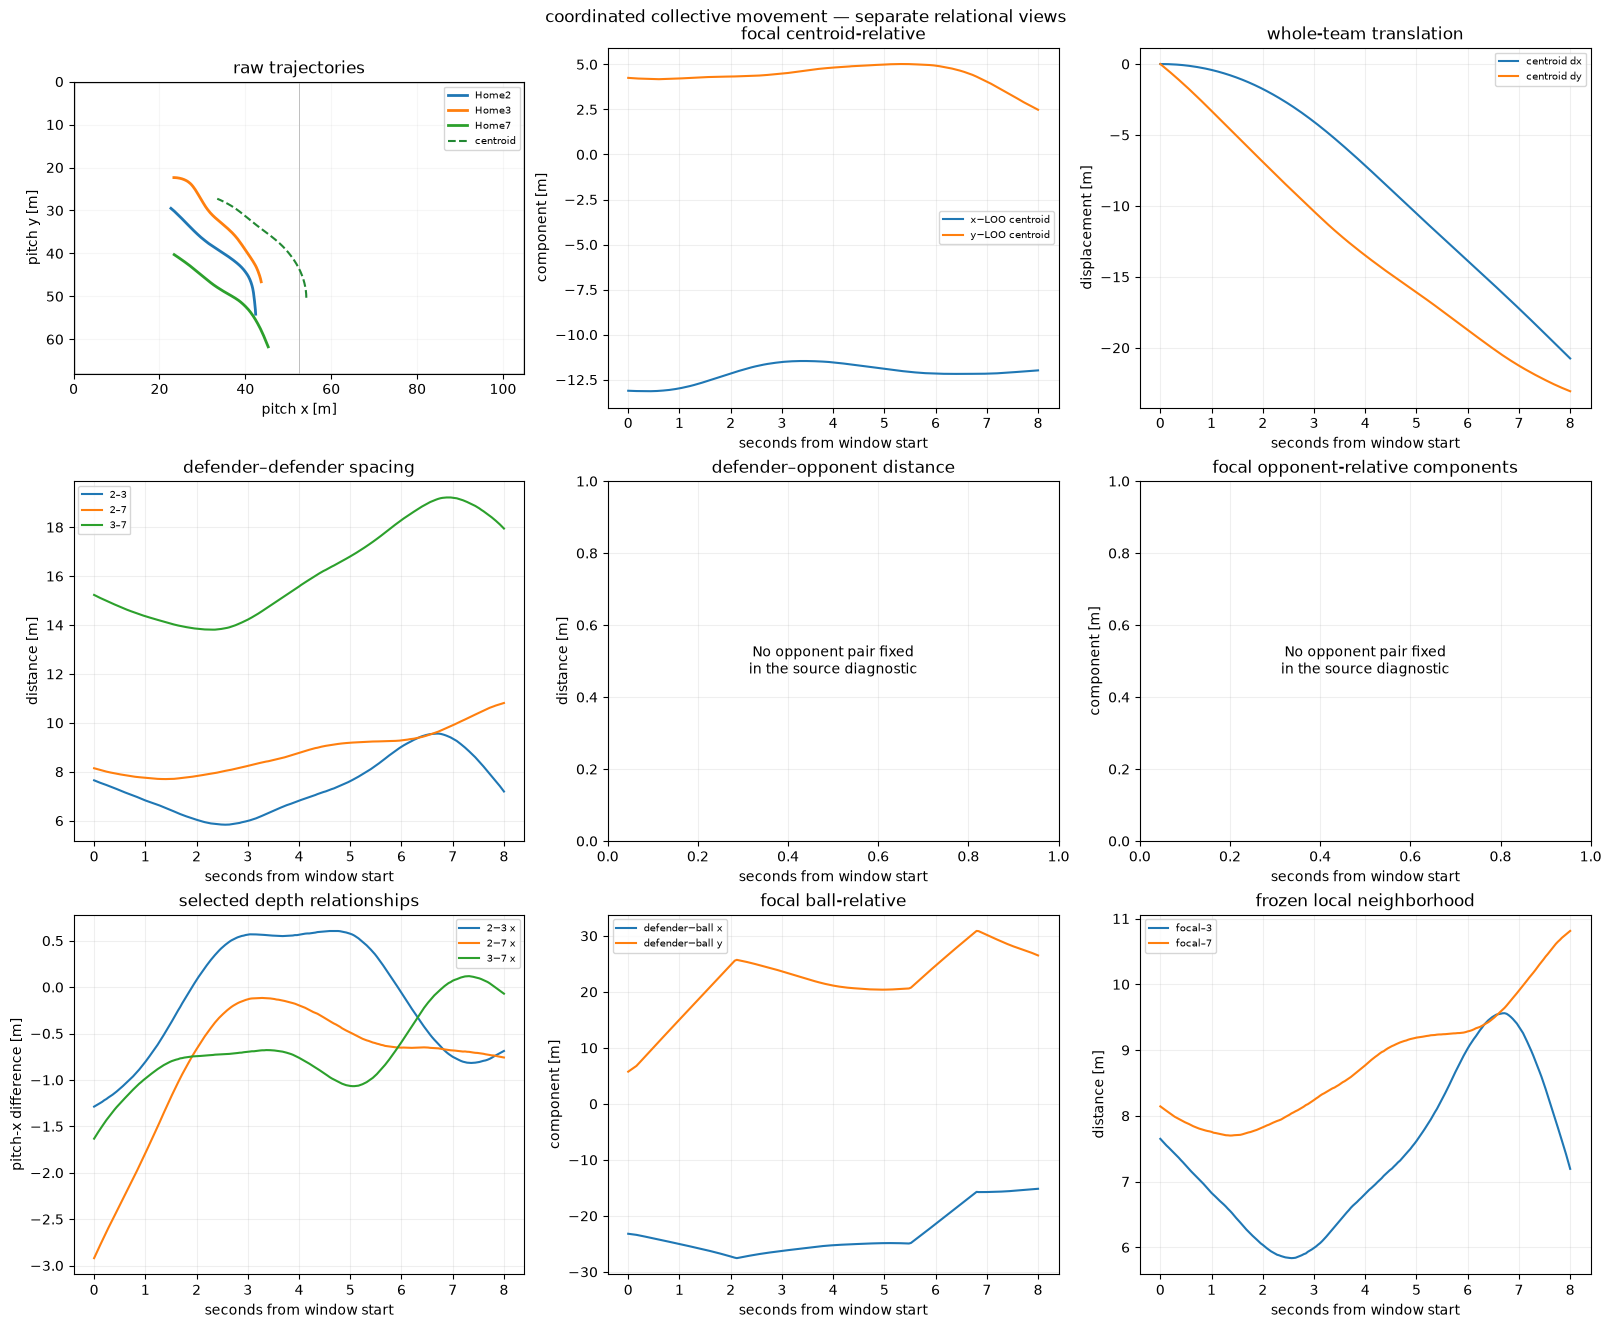

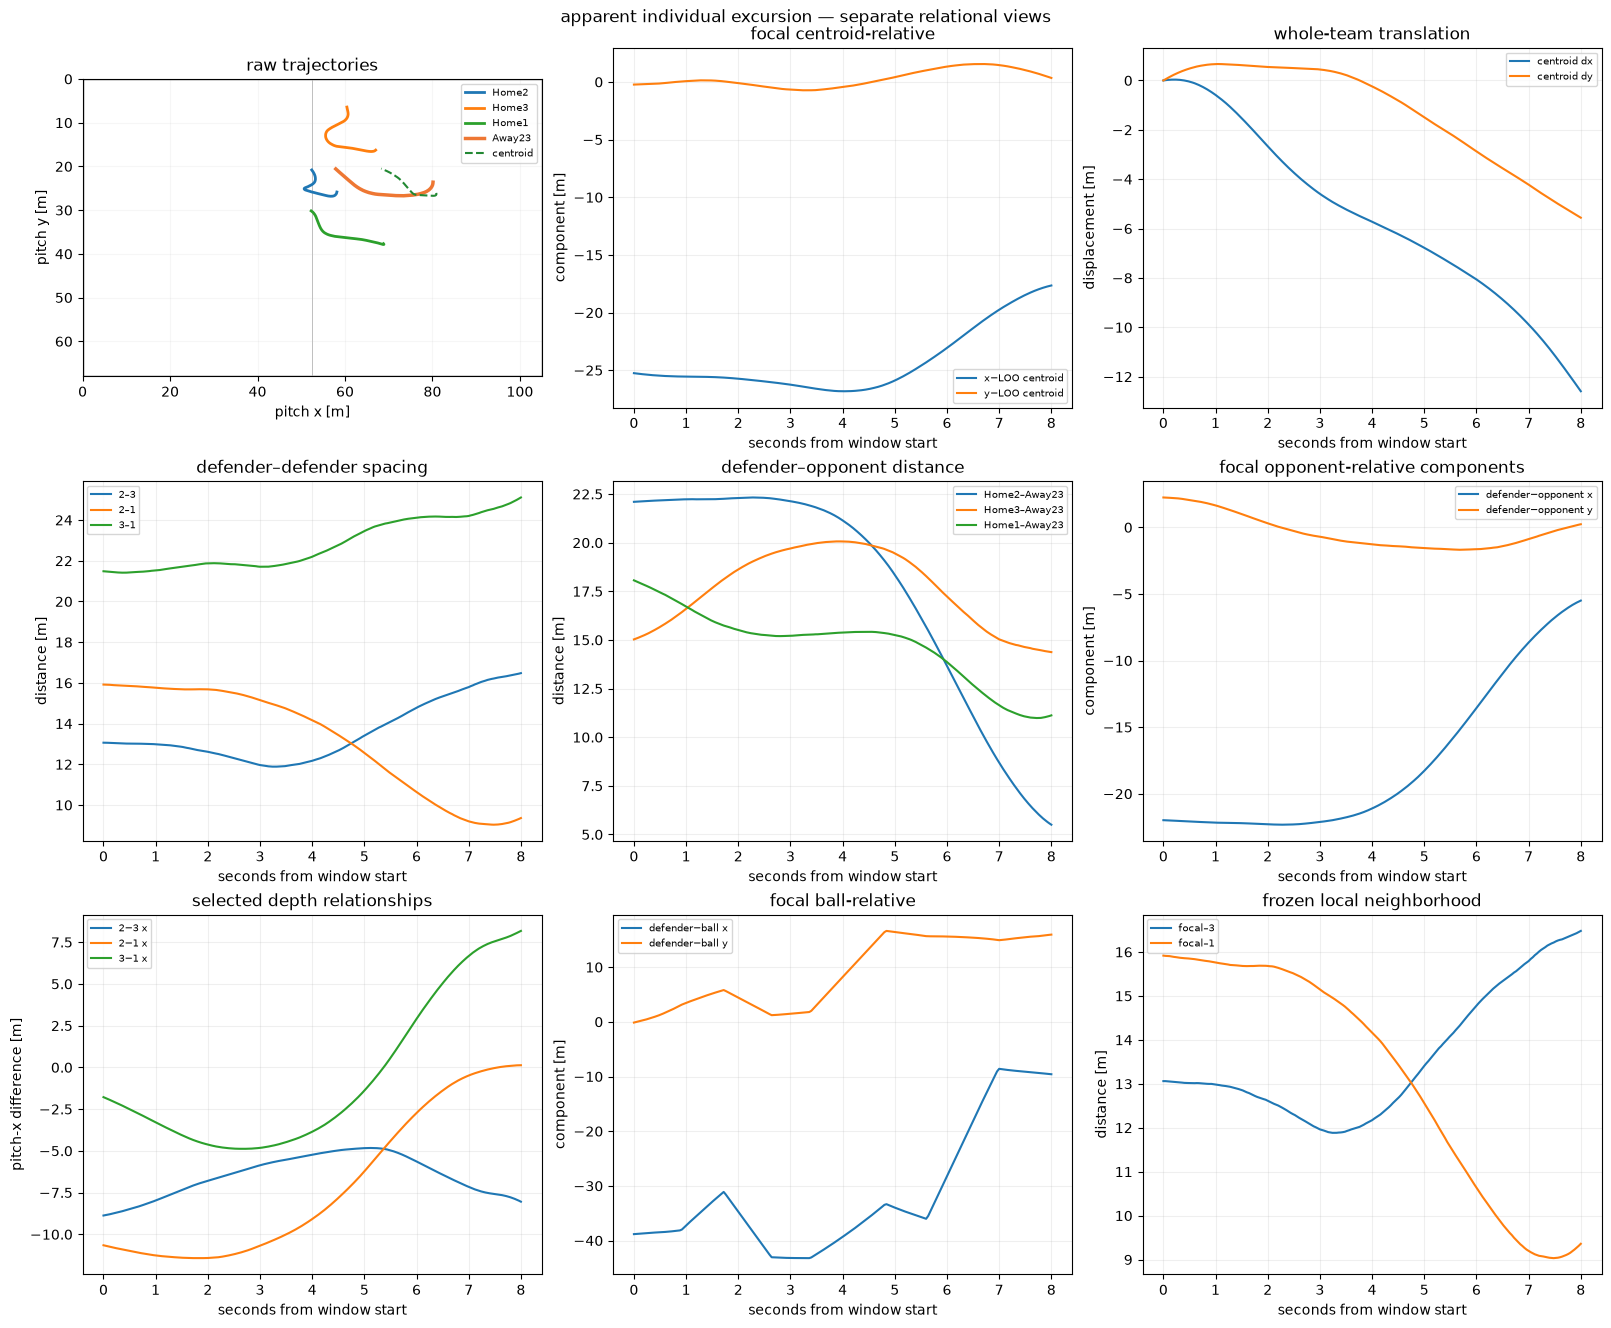

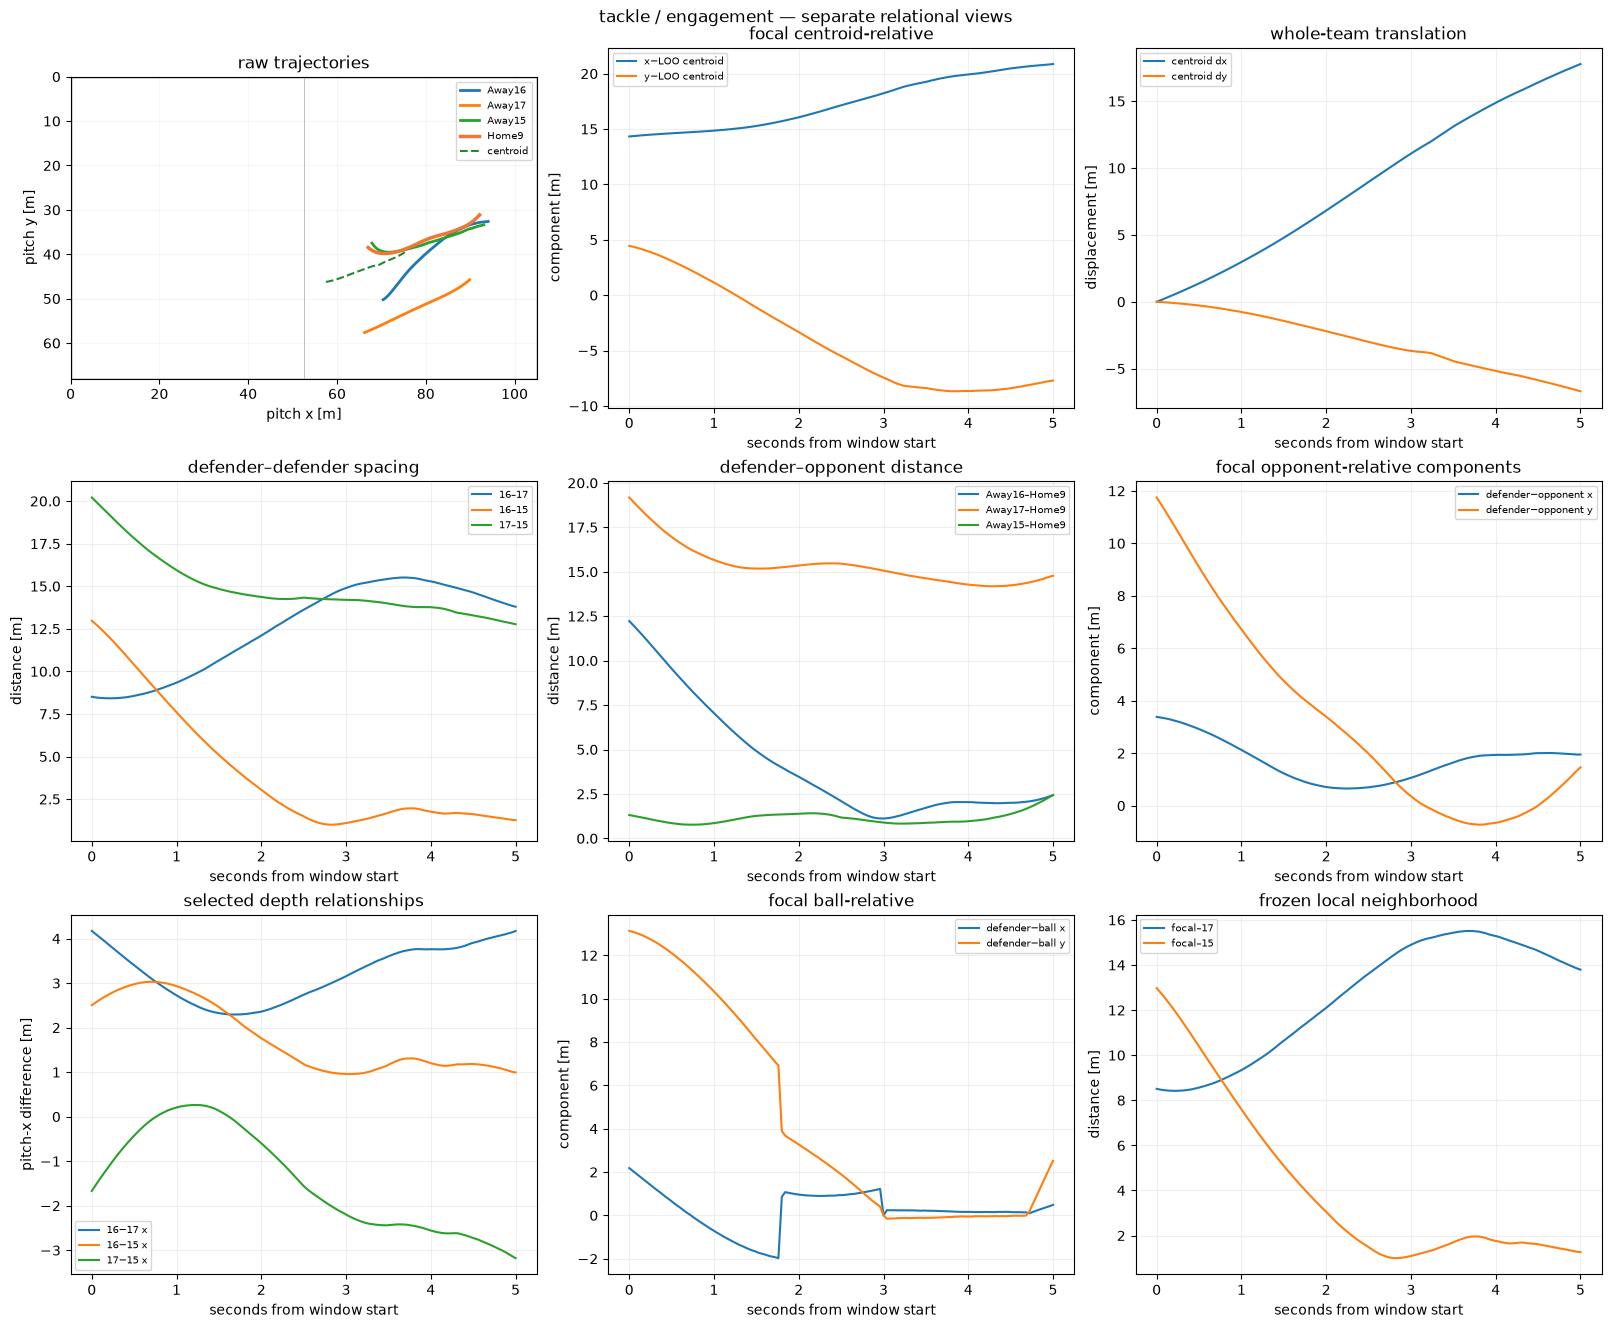

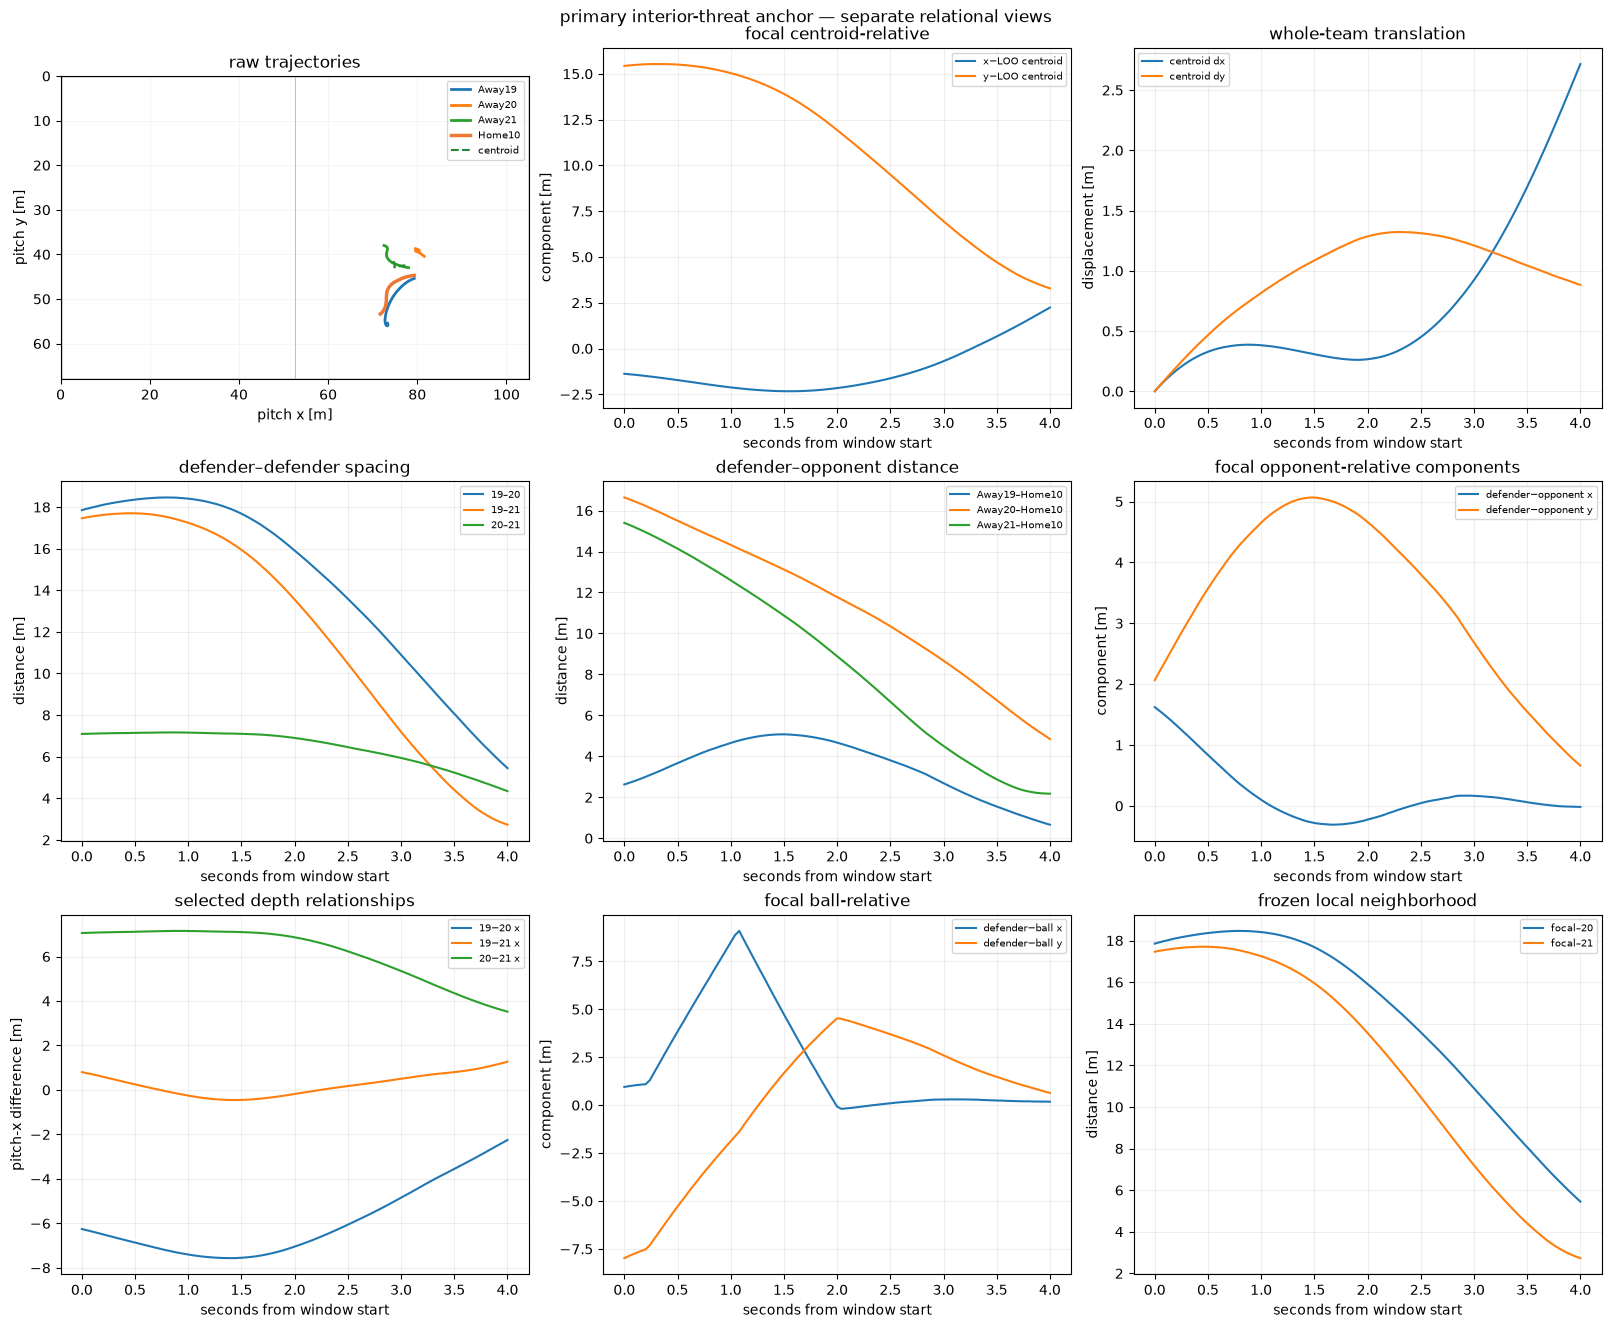

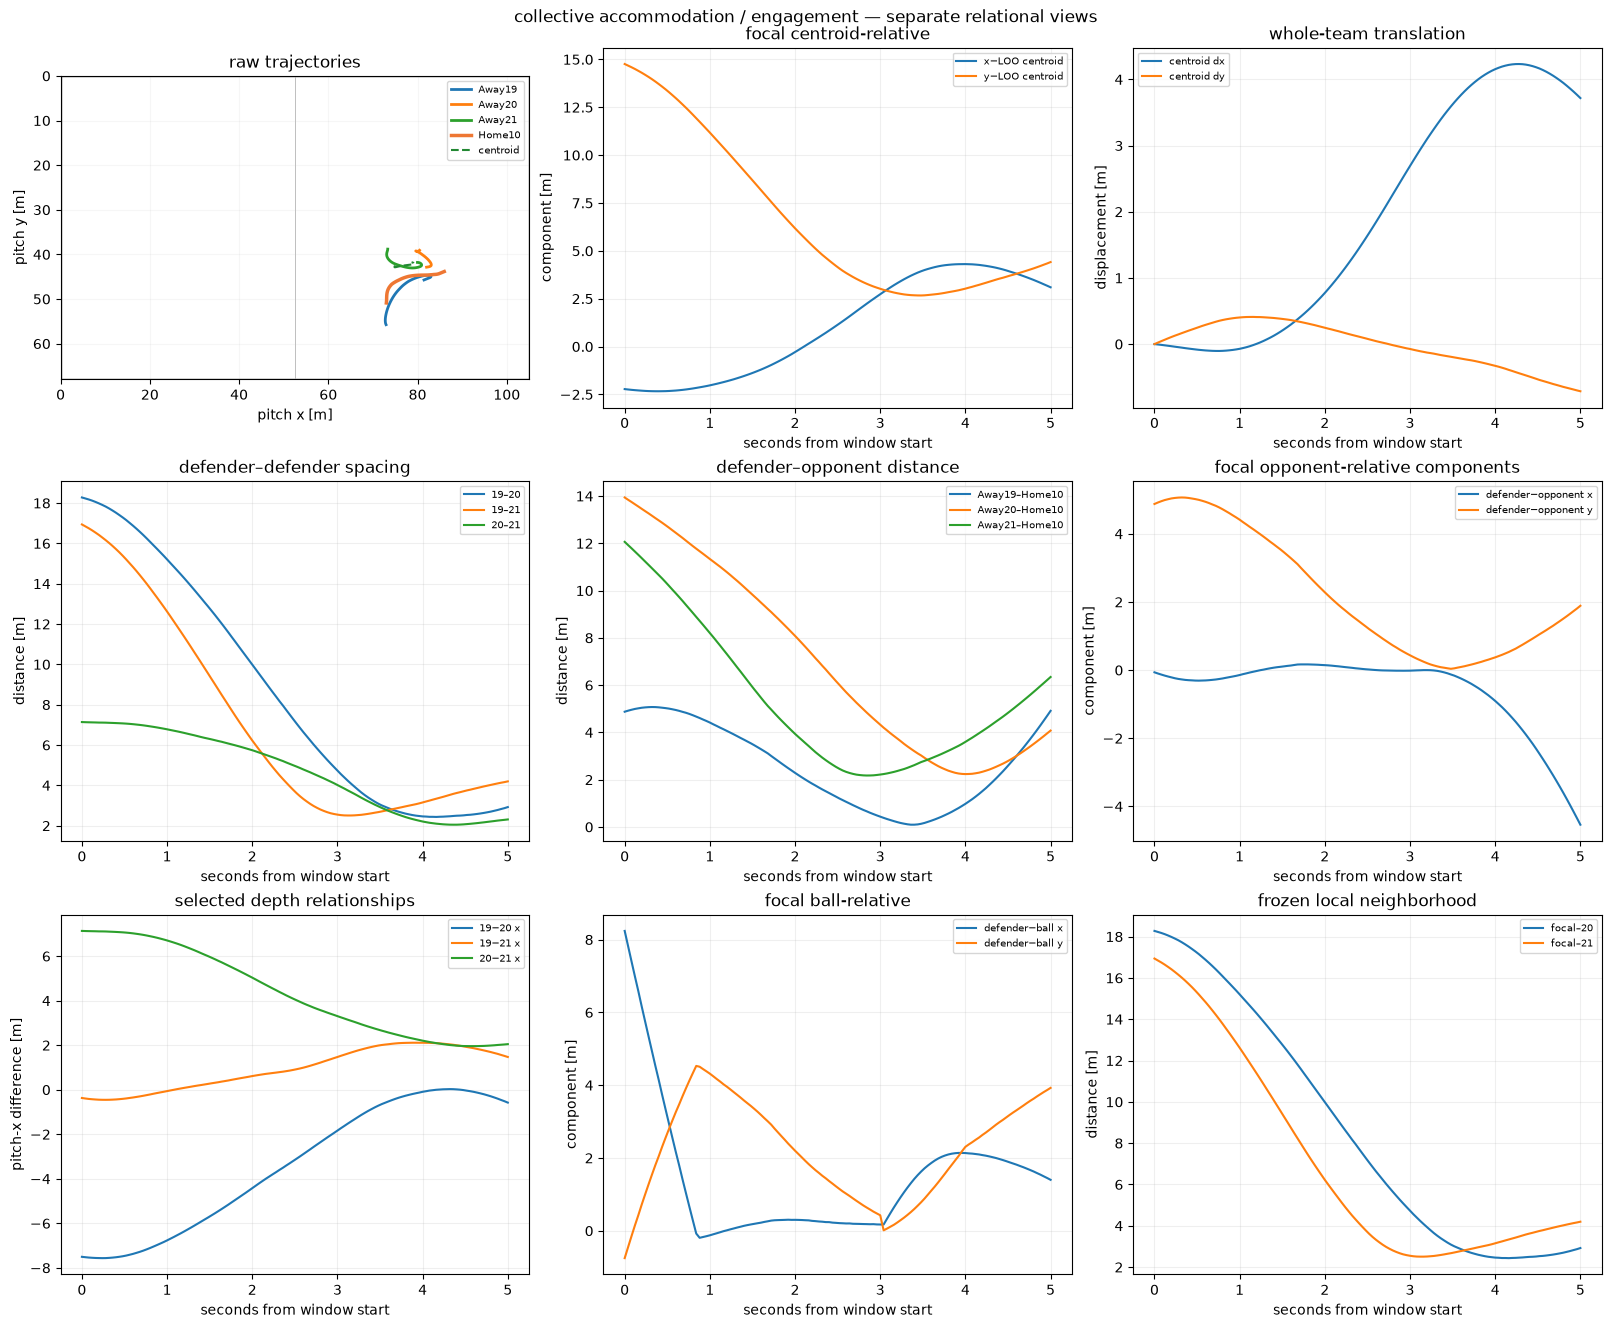

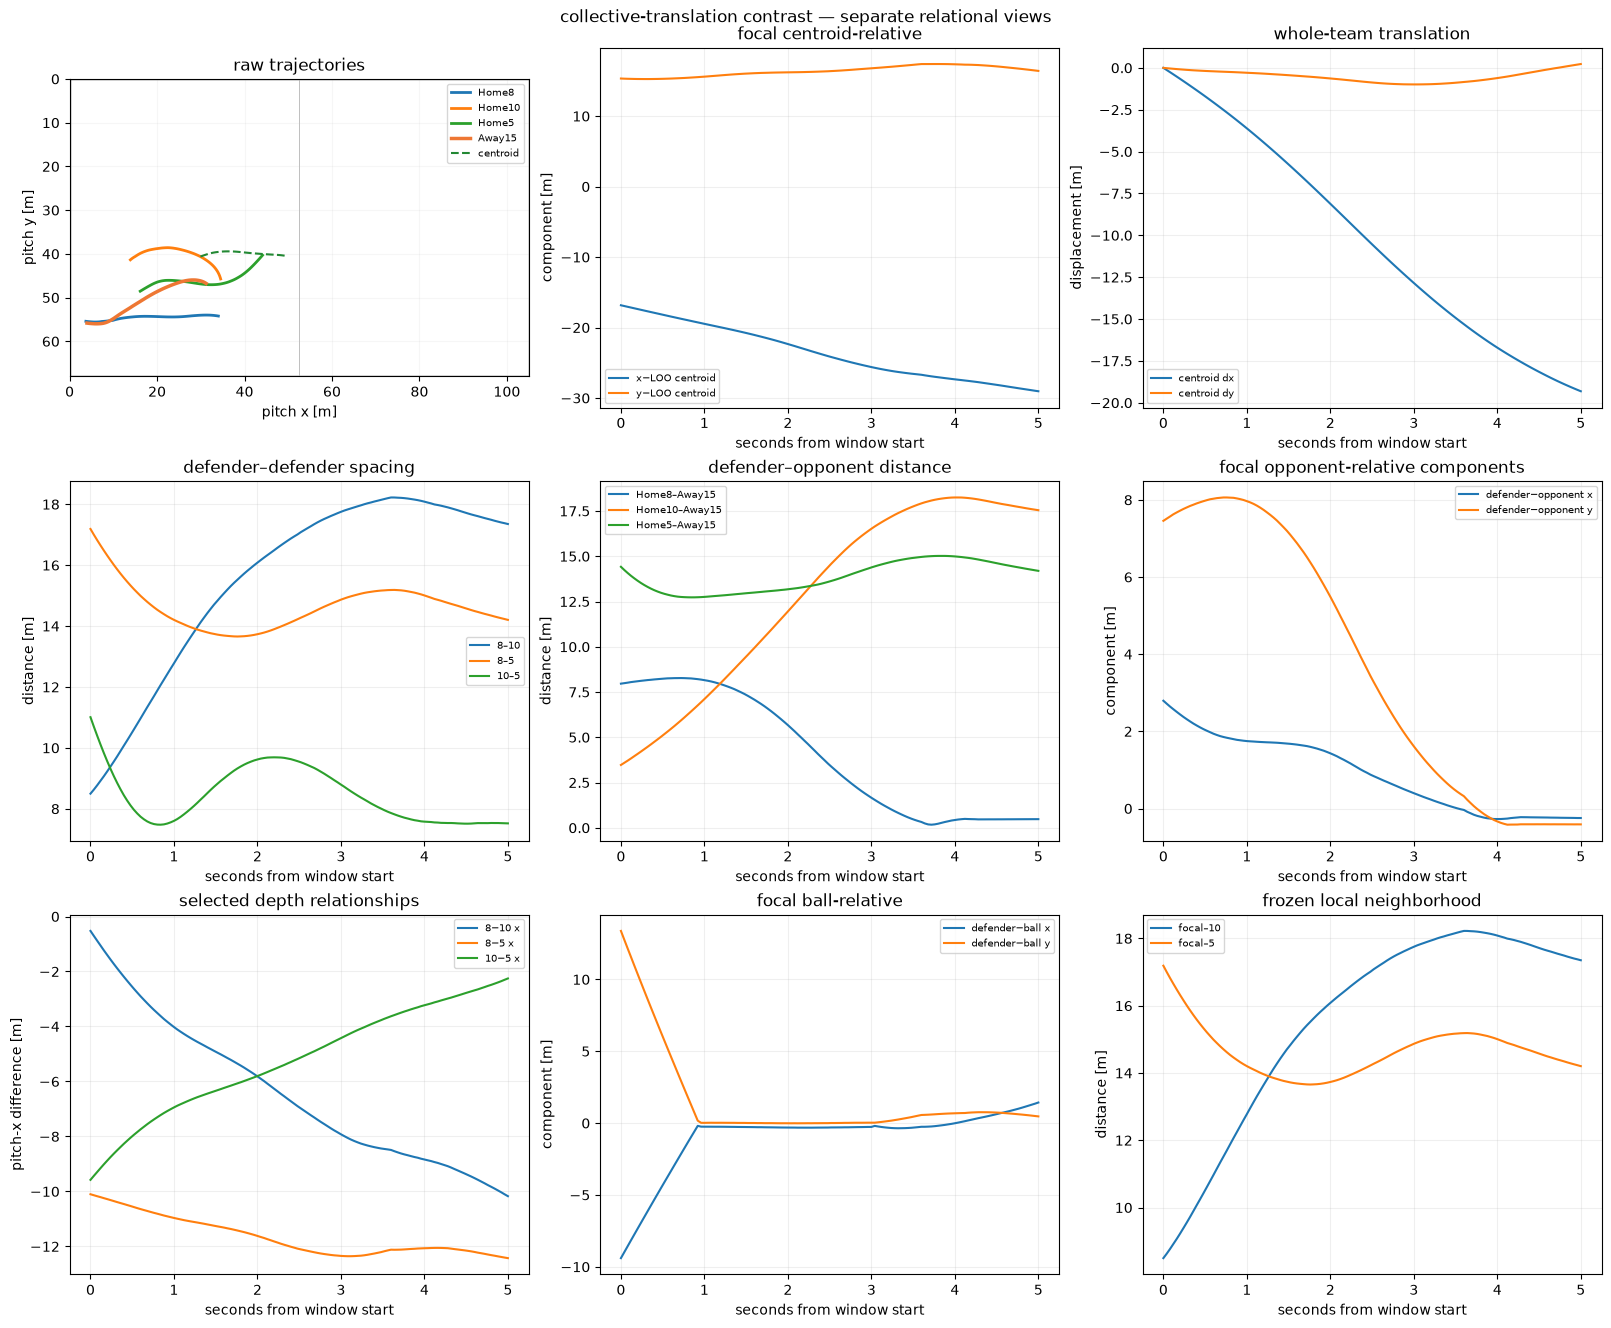

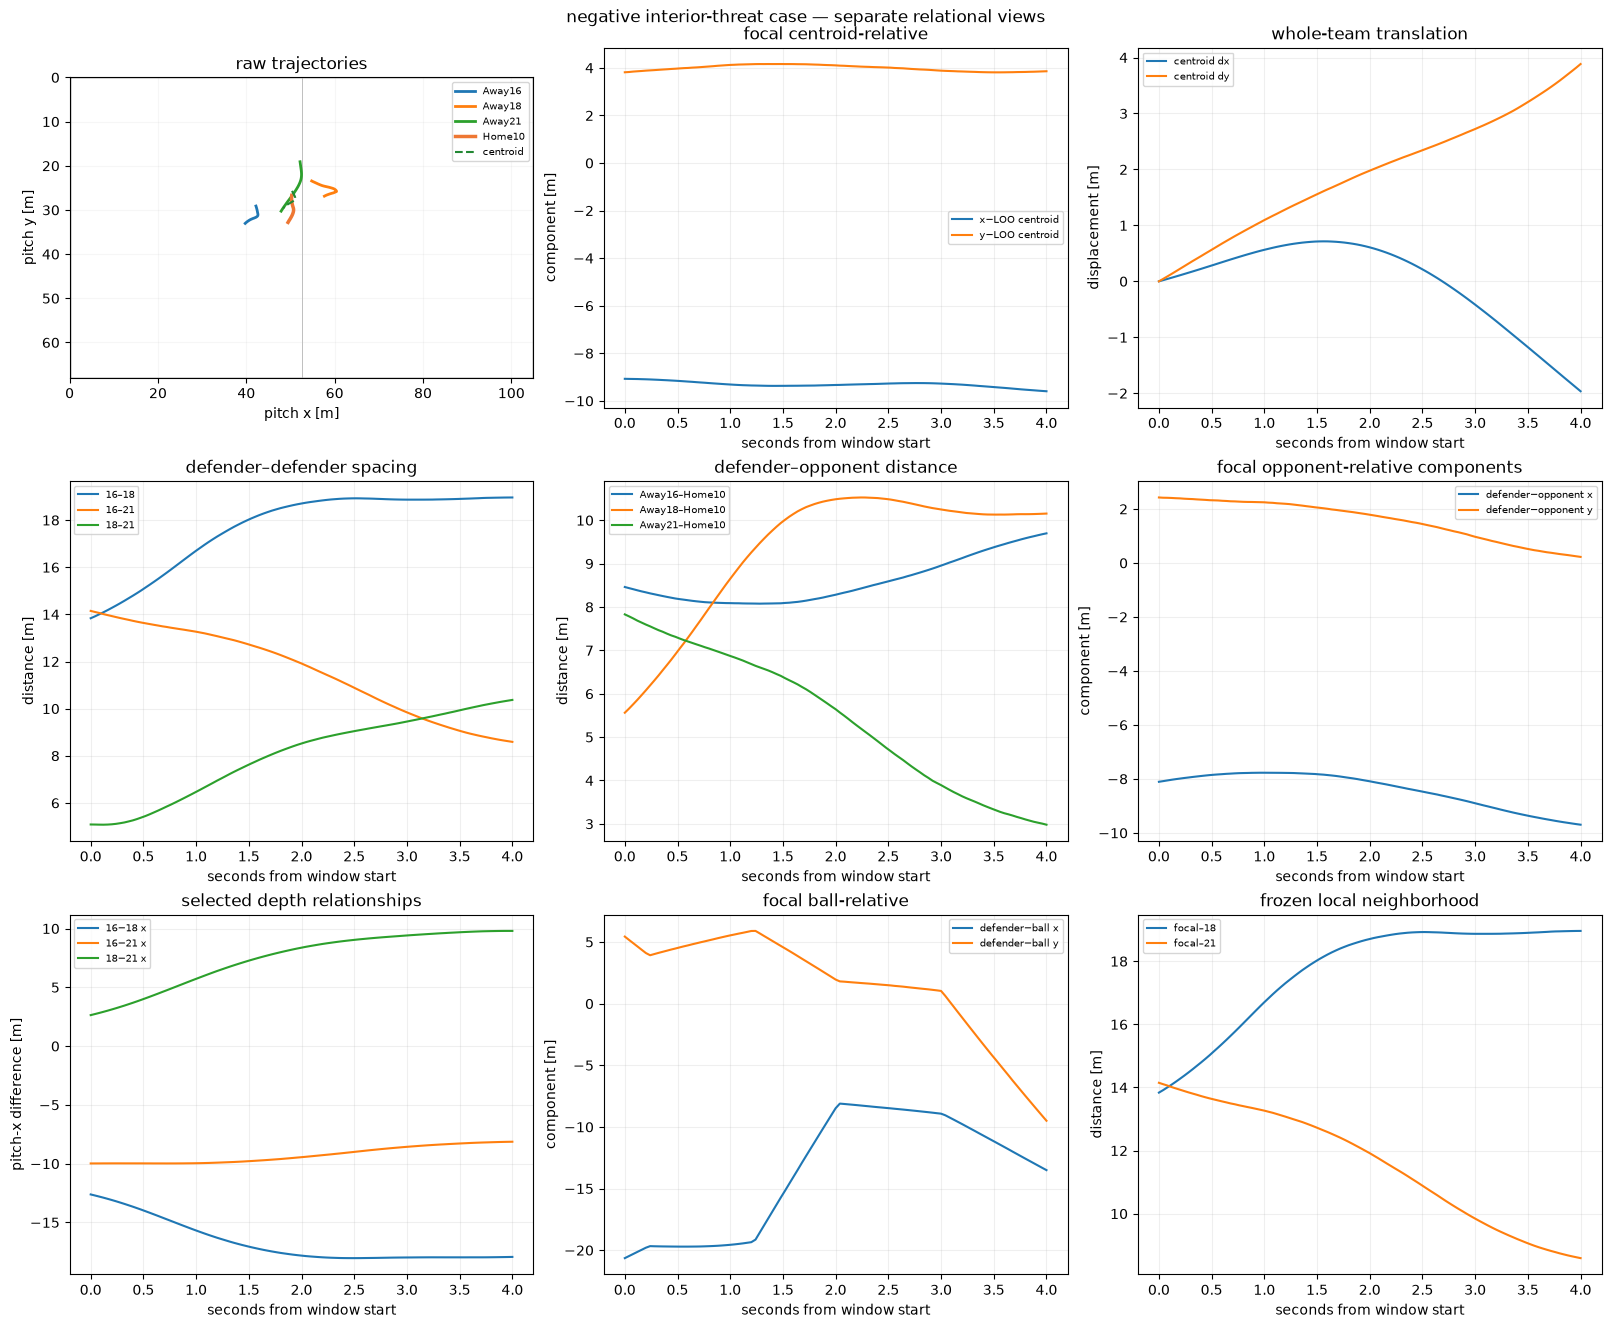

In [8]:
def representation_panels(case):
    w=add_geometry(case); dt,ot=case['def_team'],case['opp_team']; defs=case['display_defs']; t=w['Time [s]']-w['Time [s]'].iloc[0]
    fig,axes=plt.subplots(3,3,figsize=(16,13),constrained_layout=True)
    ax=axes[0,0]; pitch(ax)
    for p in defs:
        ax.plot(w[f'{dt}_{p}_x']*LENGTH,w[f'{dt}_{p}_y']*WIDTH,lw=2,label=f'{dt}{p}')
    if case['opponent']:
        ax.plot(w[f"{ot}_{case['opponent']}_x"]*LENGTH,w[f"{ot}_{case['opponent']}_y"]*WIDTH,lw=2.5,c='#ee7733',label=f"{ot}{case['opponent']}")
    ax.plot(w['centroid_x_m'],w['centroid_y_m'],ls='--',c='#228833',label='centroid'); ax.legend(fontsize=7); ax.set_title('raw trajectories')

    ax=axes[0,1]; ax.plot(t,w['focal_centroid_rel_x_m'],label='x−LOO centroid'); ax.plot(t,w['focal_centroid_rel_y_m'],label='y−LOO centroid'); ax.set_title('focal centroid-relative'); ax.set_ylabel('component [m]')
    ax=axes[0,2]; ax.plot(t,w['centroid_x_m']-w['centroid_x_m'].iloc[0],label='centroid dx'); ax.plot(t,w['centroid_y_m']-w['centroid_y_m'].iloc[0],label='centroid dy'); ax.set_title('whole-team translation'); ax.set_ylabel('displacement [m]')

    ax=axes[1,0]
    for p,q in itertools.combinations(defs,2):
        dist=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH); ax.plot(t,dist,label=f'{p}–{q}')
    ax.set_title('defender–defender spacing'); ax.set_ylabel('distance [m]')

    ax=axes[1,1]
    if case['opponent']:
        for p in defs:
            dist=np.hypot((w[f'{dt}_{p}_x']-w[f"{ot}_{case['opponent']}_x"])*LENGTH,(w[f'{dt}_{p}_y']-w[f"{ot}_{case['opponent']}_y"])*WIDTH); ax.plot(t,dist,label=f'{dt}{p}–{ot}{case["opponent"]}')
    else: ax.text(.5,.5,'No opponent pair fixed\nin the source diagnostic',ha='center',va='center',transform=ax.transAxes)
    ax.set_title('defender–opponent distance'); ax.set_ylabel('distance [m]')

    ax=axes[1,2]
    if case['opponent']:
        ax.plot(t,(w[f'{dt}_{case["focal"]}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,label='defender−opponent x')
        ax.plot(t,(w[f'{dt}_{case["focal"]}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH,label='defender−opponent y')
    else: ax.text(.5,.5,'No opponent pair fixed\nin the source diagnostic',ha='center',va='center',transform=ax.transAxes)
    ax.set_title('focal opponent-relative components'); ax.set_ylabel('component [m]')

    ax=axes[2,0]
    for p,q in itertools.combinations(defs,2): ax.plot(t,(w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,label=f'{p}−{q} x')
    ax.set_title('selected depth relationships'); ax.set_ylabel('pitch-x difference [m]')

    ax=axes[2,1]; bx=w[f'{dt}_ball_x']*LENGTH; by=w[f'{dt}_ball_y']*WIDTH
    ax.plot(t,w[f'{dt}_{case["focal"]}_x']*LENGTH-bx,label='defender−ball x'); ax.plot(t,w[f'{dt}_{case["focal"]}_y']*WIDTH-by,label='defender−ball y'); ax.set_title('focal ball-relative'); ax.set_ylabel('component [m]')

    ax=axes[2,2]
    for p in defs:
        if p==case['focal']: continue
        dist=np.hypot((w[f'{dt}_{case["focal"]}_x']-w[f'{dt}_{p}_x'])*LENGTH,(w[f'{dt}_{case["focal"]}_y']-w[f'{dt}_{p}_y'])*WIDTH); ax.plot(t,dist,label=f'focal–{p}')
    ax.set_title('frozen local neighborhood'); ax.set_ylabel('distance [m]')

    for ax in axes.flat:
        if ax is not axes[0,0]: ax.set_xlabel('seconds from window start'); ax.grid(alpha=.2)
        handles,labels=ax.get_legend_handles_labels()
        if handles: ax.legend(fontsize=7)
    fig.suptitle(f"{case['name']} — separate relational views",y=1.01)
    plt.show()

for case in CASES:
    representation_panels(case)

## Direct descriptive quantities

These quantities summarize visible changes without ranking representations. Spans retain x and y separately. Start-to-end changes can hide reversals, so the trajectory and time-series figures remain primary.

In [9]:
def descriptive_row(case):
    w=add_geometry(case); dt,ot=case['def_team'],case['opp_team']; defs=case['display_defs']
    row={'case':case['name'],
         'centroid_dx_m':w['centroid_x_m'].iloc[-1]-w['centroid_x_m'].iloc[0],
         'centroid_dy_m':w['centroid_y_m'].iloc[-1]-w['centroid_y_m'].iloc[0],
         'focal_centroid_rel_x_span_m':w['focal_centroid_rel_x_m'].max()-w['focal_centroid_rel_x_m'].min(),
         'focal_centroid_rel_y_span_m':w['focal_centroid_rel_y_m'].max()-w['focal_centroid_rel_y_m'].min()}
    dd=[]
    for p,q in itertools.combinations(defs,2):
        s=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH); dd.append(s.iloc[-1]-s.iloc[0])
    row['mean_selected_DD_distance_change_m']=np.mean(dd)
    if case['opponent']:
        d=np.hypot((w[f'{dt}_{case["focal"]}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,(w[f'{dt}_{case["focal"]}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH)
        row['focal_opponent_distance_change_m']=d.iloc[-1]-d.iloc[0]
    else: row['focal_opponent_distance_change_m']=np.nan
    bx=w[f'{dt}_ball_x']*LENGTH; by=w[f'{dt}_ball_y']*WIDTH
    brx=w[f'{dt}_{case["focal"]}_x']*LENGTH-bx; bry=w[f'{dt}_{case["focal"]}_y']*WIDTH-by
    row['focal_ball_rel_x_span_m']=brx.max()-brx.min(); row['focal_ball_rel_y_span_m']=bry.max()-bry.min()
    return row

descriptive=pd.DataFrame([descriptive_row(c) for c in CASES]).set_index('case')
display(descriptive.round(3))

,centroid_dx_m,centroid_dy_m,focal_centroid_rel_x_span_m,focal_centroid_rel_y_span_m,mean_selected_DD_distance_change_m,focal_opponent_distance_change_m,focal_ball_rel_x_span_m,focal_ball_rel_y_span_m
case,,,,,,,,
coordinated collective movement,-20.749,-23.060,1.678,2.538,1.642,NaN,12.382,25.127
apparent individual excursion,-12.590,-5.559,9.171,2.278,0.162,-16.597,34.621,16.759
tackle / engagement,17.776,-6.689,6.541,13.123,-4.620,-9.792,4.155,13.281
primary interior-threat anchor,2.716,0.883,4.568,12.251,-9.961,-1.963,9.282,12.508
collective accommodation / engagement,3.719,-0.713,6.641,12.088,-10.975,0.037,8.433,5.282
collective-translation contrast,-19.313,0.229,12.199,2.133,0.794,-7.485,10.829,13.388
negative interior-threat case,-1.965,3.884,0.523,0.350,1.618,1.237,12.536,15.400


## Representation comparison

| Representation | What it preserves | What it misses | Failure mode |
|---|---|---|---|
| Whole-team / leave-one-out centroid-relative coordinates | Collective translation baseline; focal deviation from a team mean | Which local or opponent relationships changed; rotation, compression, splitting, cancellation | Stable centroid can coexist with substantial reorganization; mean may occupy tactically empty space |
| Defender–defender pairwise geometry | Local spacing, compression/expansion, relative depth, opposing movements | Ball/opponent context; which relation matters; collective translation | Tightening can be appropriate or harmful; all pairs become unwieldy and tactically indiscriminate |
| Defender–opponent pairwise geometry | Threat-relative and secondary-opponent changes; separate x/y and distance | Responsibility, passing access, cover, intent, team context | Distance change can be mistaken for marking, openness, or defensive quality |
| Clearly interpretable depth relationships | Line/depth staggering among selected defenders without collapsing x/y | Lateral coverage, ball context, non-line organization | “Line” membership can be imposed by the analyst; pitch orientation and phase matter |
| Ball-relative position | Shared response to ball movement; ball-side/depth changes | Opponent-specific response and teammate coordination | Ball motion can dominate and be mistaken for individualized engagement |
| Frozen local neighborhood | Nearby teammate spacing and local accommodation around a focal defender | Distant cover and changing neighborhood membership; opponent/ball meaning | Nearest-at-start is not a tactical unit; dynamic nearest sets can create artificial discontinuities |

No single row is proposed as the answer. The comparison asks which information must coexist while remaining interpretable.

## Diagnostic findings and provisional requirement

The 1230.12 s anchor confirms the information loss directly. Whole-team centroid movement is small compared with the changing positions of Away19/20/21; their movements partly cancel. Defender–defender spacing and depth views preserve local convergence and reordering, while defender–opponent components preserve changes around Home10 and selected secondary attackers. Ball-relative coordinates add phase context but cannot distinguish opponent-specific response by themselves.

Across the controls, centroid-relative coordinates are useful for coordinated translation and focal deviation, but do not describe *which* relations changed. Pairwise defender geometry captures local compression but is not meaningful without opponent and ball context. Defender–opponent geometry captures engagement-like changes but cannot establish responsibility or openness and misses teammate compensation. The negative 4197.04 s case is important: a visually plausible dense situation does not become coherent multi-defender convergence merely because several pairwise views are available.

The provisional minimum is therefore not a composite number. It is a small **typed relational description** retaining: (1) an absolute pitch/collective-translation baseline; (2) focal and local defender–defender x/y geometry; (3) selected defender–opponent x/y relations, including secondary opponents when soccer context justifies inspection; and (4) ball-relative context. Clearly interpretable depth relationships are useful conditional views, not universally valid inferred lines. The relationships must stay typed and sparse enough that adding arbitrary pairs cannot explain every movement after the fact.

This remains a diagnostic requirement, not a final representation. No score, ranking, network, assignment inference, clustering, HMM, ML model, optimized threshold, causal claim, style model, gravity metric, or new dataset is introduced. Phase 2A stops here.